In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [31]:
df = pd.read_csv(
    'Car Price.csv'
)

print(df.head())

     Brand                     Model  Year  Selling_Price  KM_Driven    Fuel  \
0   Maruti             Maruti 800 AC  2007          60000      70000  Petrol   
1   Maruti  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2  Hyundai      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3   Datsun    Datsun RediGO T Option  2017         250000      46000  Petrol   
4    Honda     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  Seller_Type Transmission         Owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [32]:
print(df.shape)

print(df.info())

(4340, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Brand          4340 non-null   object
 1   Model          4340 non-null   object
 2   Year           4340 non-null   int64 
 3   Selling_Price  4340 non-null   int64 
 4   KM_Driven      4340 non-null   int64 
 5   Fuel           4340 non-null   object
 6   Seller_Type    4340 non-null   object
 7   Transmission   4340 non-null   object
 8   Owner          4340 non-null   object
dtypes: int64(3), object(6)
memory usage: 305.3+ KB
None


In [33]:
print(df.describe())

              Year  Selling_Price      KM_Driven
count  4340.000000   4.340000e+03    4340.000000
mean   2013.090783   5.041273e+05   66215.777419
std       4.215344   5.785487e+05   46644.102194
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   8.900000e+06  806599.000000


In [34]:
print(df.isnull().sum())

Brand            0
Model            0
Year             0
Selling_Price    0
KM_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [35]:
numeric_df = df.select_dtypes(
    include=['number']
)

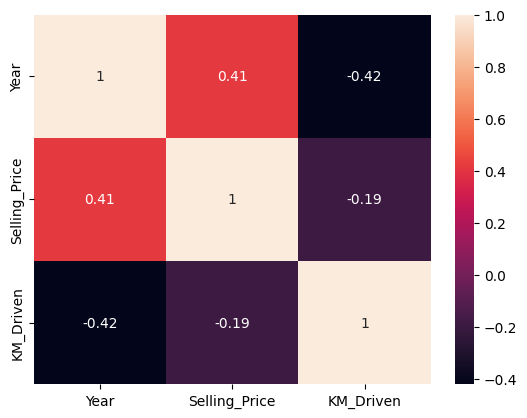

In [36]:
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

In [37]:
X = numeric_df.drop(
    'Selling_Price',
    axis=1
)

y = numeric_df['Selling_Price']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [41]:
print(
    "R2 Score:",
    r2_score(y_test, y_pred)
)

R2 Score: 0.1620831376822649


In [42]:
print(
    "Mean Absolute Error:",
    mean_absolute_error(
        y_test,
        y_pred
    )
)

Mean Absolute Error: 256362.48559820454


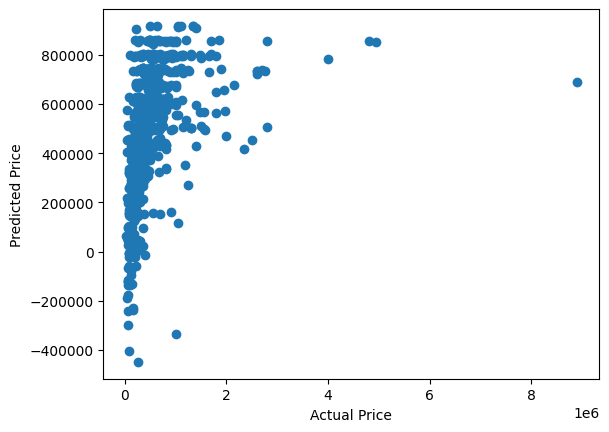

In [43]:
plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.show()